# Conversion Prediction Model

# Objective
**Problem:** Predict which free-tier (non-customer) companies are likely to convert to paying customers within the next 30 days.

**Output:** Weekly prioritized list (generated on Sundays).

# Assumptions
+ Alexa rank Null means that the company has no webpage, thus we assign 16000001 to these cases

# Table of Contents

In [1]:
import logging
from pathlib import Path
from typing import Tuple, List, Dict, Optional

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display, IFrame
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from ydata_profiling import ProfileReport

%matplotlib inline

# Custom libs
from data_prep import missing_summary, encode_industries
from features import VectorizedUsageFeatureBacktester

# Constants

In [2]:
ACTION_COLS = ["ACTIONS_CRM_CONTACTS", "ACTIONS_CRM_COMPANIES", "ACTIONS_CRM_DEALS", "ACTIONS_EMAIL"]
USER_COLS   = ["USERS_CRM_CONTACTS", "USERS_CRM_COMPANIES", "USERS_CRM_DEALS", "USERS_EMAIL"]
METRIC_COLS = ACTION_COLS + USER_COLS
WINDOWS     = {"7d": 7, "14d": 14, "30d": 30, "60d": 60}
PREDICTION_HORIZON_DAYS = 30

EMPLOYEE_RANGE_TO_MID = {
    "1": 1.0,
    "2 to 5": 3.0,
    "6 to 10": 8.0,
    "11 to 25": 18.0,
    "26 to 50": 38.0,
    "51 to 200": 125.0,
    "201 to 1000": 600.0,
    "1001 to 10000": 5500.0,
    "10,001 or more": 10001.0,
}

# Load Data
- Load data
- Preprocess and standardize columns
- Check data integrity and basic statistics

In [3]:

# Load data
customers_df = pd.read_csv("../data/customers.csv")
noncustomers_df = pd.read_csv("../data/noncustomers.csv")
usage_actions_df = pd.read_csv("../data/usage_actions.csv")

# Parse dates
customers_df['CLOSEDATE'] = pd.to_datetime(customers_df['CLOSEDATE'])
usage_actions_df['WHEN_TIMESTAMP'] = pd.to_datetime(usage_actions_df['WHEN_TIMESTAMP'])

# Sort by CLOSEDATE and WHEN_TIMESTAMP
customers_df = customers_df.sort_values(by=['CLOSEDATE'])
usage_actions_df = usage_actions_df.sort_values(by=['WHEN_TIMESTAMP'])

# All columns to upper case
customers_df.columns = customers_df.columns.str.upper()
noncustomers_df.columns = noncustomers_df.columns.str.upper()
usage_actions_df.columns = usage_actions_df.columns.str.upper()


# Check data
print(f"customers:     {customers_df.shape}  — IDs {customers_df['ID'].min()}–{customers_df['ID'].max()}")
print(f"noncustomers:  {noncustomers_df.shape}  — IDs {noncustomers_df['ID'].min()}–{noncustomers_df['ID'].max()}")
print(f"usage_actions: {usage_actions_df.shape}")
print(f"Usage date range: {usage_actions_df['WHEN_TIMESTAMP'].min().date()} → {usage_actions_df['WHEN_TIMESTAMP'].max().date()}")
print(f"Unique ids: {usage_actions_df['ID'].nunique()}")

cust_ids   = set(customers_df["ID"])
noncust_ids= set(noncustomers_df["ID"])
print(f"ID overlap (customers ∩ noncustomers): {len(cust_ids & noncust_ids)}")  

REF_DATE = usage_actions_df["WHEN_TIMESTAMP"].max()
print(f"Reference date ('today'): {REF_DATE.date()}")


customers:     (200, 6)  — IDs 1–200
noncustomers:  (5003, 4)  — IDs 201–5200
usage_actions: (25387, 10)
Usage date range: 2019-01-07 → 2020-07-27
Unique ids: 3569
ID overlap (customers ∩ noncustomers): 0
Reference date ('today'): 2020-07-27


# EDA
+ Missing values
+ Using ydata_profiling for detailed and shareable insights found in ./reports

In [4]:
# Check missing data
missing_summary(customers_df, "CUSTOMERS")
missing_summary(noncustomers_df, "NON-CUSTOMERS")
missing_summary(usage_actions_df, "USAGE")



CUSTOMERS columns with missing values:
        column  missing_count  missing_pct
      INDUSTRY            129         64.5
EMPLOYEE_RANGE              2          1.0

NON-CUSTOMERS columns with missing values:
        column  missing_count  missing_pct
      INDUSTRY           3725        74.46
EMPLOYEE_RANGE            532        10.63
    ALEXA_RANK            114         2.28

USAGE columns with missing values:
None


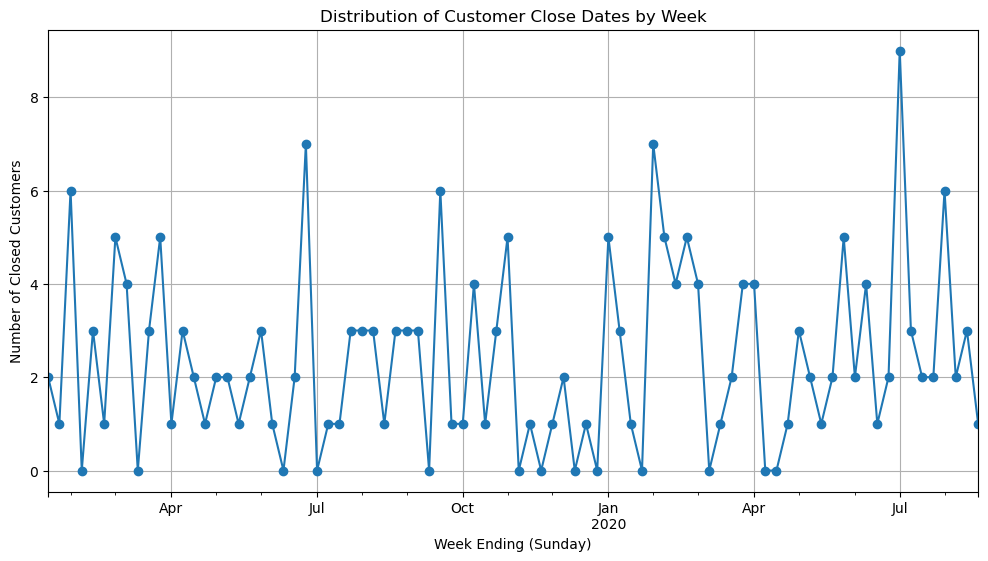

In [22]:
# Example: ensure CLOSEDATE is datetime
customers_df['CLOSEDATE'] = pd.to_datetime(customers_df['CLOSEDATE'])

# Distribution of close dates
# Resample to weekly frequency (ending on Sunday) and count
weekly_closes = customers_df.set_index('CLOSEDATE').resample('W-SUN').size()

# Plot it with x as closedate and y the counter
plt.figure(figsize=(12, 6))
plt.plot(weekly_closes.index, weekly_closes.values, marker='o', linestyle='-')
plt.title('Weekly Customer Conversions (Ending Sunday)')
plt.xlabel('Week Ending Date')
plt.ylabel('Number of Conversions')
plt.grid(True)
plt.show()

# Display the data
weekly_closes

In [5]:
# Usage-level comparison: customers vs non-customers
usage_customers_df = usage_actions_df[usage_actions_df["ID"].isin(cust_ids)].copy()
usage_noncustomers_df = usage_actions_df[usage_actions_df["ID"].isin(noncust_ids)].copy()

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

usage_customer_profile = ProfileReport(usage_customers_df, title="Customer Usage", minimal=True)
usage_noncustomer_profile = ProfileReport(usage_noncustomers_df, title="Non-customer Usage", minimal=True)

usage_customer_profile.compare(usage_noncustomer_profile).to_file(reports_dir / "usage_comparison.html")

display(IFrame(src=str(reports_dir / "usage_comparison.html"), width="100%", height=600))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 5080.31it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 1101.97it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
# Company-level comparison: customers vs non-customers
historical_customers_df = customers_df[customers_df["CLOSEDATE"] <= REF_DATE].copy()

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

customer_profile    = ProfileReport(historical_customers_df, title="Customers",     minimal=True)
noncustomer_profile = ProfileReport(noncustomers_df,         title="Non-customers", minimal=True)

customer_profile.compare(noncustomer_profile).to_file(reports_dir / "company_comparison.html")

display(IFrame(src=str(reports_dir / "company_comparison.html"), width="100%", height=600))

c:\Users\totic\anaconda3\Lib\site-packages\ydata_profiling\compare_reports.py:191: UserWarning: The datasets being profiled have a different set of columns. Only the left side profile will be calculated.
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 953.90it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 285.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Main Takeaways from the Analysis

### 1. Company Profile Differences
*   **Size Matters:** Converting customers are typically slightly larger. They are most frequently in the **6–50 employee range** (especially 6–10 employees). Non-customers skew heavily towards very small teams (1–5 employees), with **13.4%** having just 1 employee (vs. only 0.5% for customers).
*   **Industry Focus:** **Computer Software** and **Technology** companies are much more likely to convert. `COMPUTER_SOFTWARE` accounts for ~20% of customers compared to ~16% of non-customers.
*   **Web Presence:** Customers have significantly better web traffic. The median **Alexa Rank** for customers is **3.7M**, whereas for non-customers it is **16M** (often indicating no ranked website). This suggests established businesses with active online footprints are better prospects.

### 2. Usage Behavior (Strongest Signal)
*   **Massive Activity Gap:** Customers are exponentially more active in the product.
    *   **CRM Contacts:** Customers perform ~15x more actions (223 vs. 15 avg).
    *   **CRM Deals:** Customers perform ~13x more actions (75 vs. 6 avg).
    *   **CRM Companies:** Customers perform ~10x more actions (46 vs. 5 avg).
*   **Team Adoption:** The most critical differentiator is likely **multi-user adoption**. Customers average **~5.3 users** interacting with contacts, whereas non-customers average **<1 user** (0.7).
*   **Feature Usage:**
    *   **Contacts** is the "gateway" feature: only 18% of customers have zero usage here, compared to 56% of non-customers.
    *   **Email** is a power-user feature: while usage is generally lower, customers are 20x more active with email features than non-customers.

### Summary
The ideal conversion candidate is a **Tech/Software company with 6–50 employees** that has **integrated the CRM into their team workflow** (5+ users) and is actively managing a high volume of **Contacts and Deals**. Single-user accounts with low data entry are unlikely to convert.

# Feature Engineering
+ Assumption: Alexa rank Null means that the company has no webpage, thus we assign 16000001 to these cases
+ INDUSTRY nulls could be reduced by doing Web Scraping or buying a company industry database
+ Employee range to the middle of the range
+ One Hot Encoding of INDUSTRY
+ Build date features

In [7]:
# Concat users and non users
companies_df = pd.concat([customers_df, noncustomers_df], axis=0, ignore_index=True)

# Force specific critical types (like Datetime) if convert_dtypes is too conservative
companies_df['CLOSEDATE'] = pd.to_datetime(companies_df['CLOSEDATE'], errors='coerce')

print(f"Merged companies_df shape: {companies_df.shape}")

Merged companies_df shape: (5203, 6)


In [8]:
# For null ALEXA_RANK assume they where not found and page-rank will be weak
max_rank = companies_df['ALEXA_RANK'].max()
companies_df['ALEXA_RANK'] = np.where(companies_df['ALEXA_RANK'].isnull(), max_rank, companies_df['ALEXA_RANK'])

In [9]:
# Employee range to numberic
# For a better comparison, map EMPLOYEE_RANGE with explicit dictionaries.
companies_df["EMPLOYEE_RANGE"] = companies_df["EMPLOYEE_RANGE"].map(EMPLOYEE_RANGE_TO_MID)


In [10]:
# Encoding Insustry with sklearn
companies_df = encode_industries(companies_df, 'INDUSTRY', max_cats=10)
companies_df

,CLOSEDATE,MRR,ALEXA_RANK,EMPLOYEE_RANGE,INDUSTRY,ID,IND_CONSULTING,IND_EDUCATION,IND_FINANCE,IND_SERVICES,IND_MARKETING,IND_OTHER,IND_REAL ESTATE,IND_TECH,IND_UNKNOWN,IND_sklearn
0,2019-01-15,300.96,16000001.0,8.0,NaN,42,0,0,0,0,0,0,0,0,1,0
1,2019-01-17,49.07,10390859.0,3.0,NaN,20,0,0,0,0,0,0,0,0,1,0
2,2019-01-27,209.98,273063.0,38.0,Technology - Software,174,0,0,0,0,0,0,0,1,0,0
3,2019-01-30,40.00,2610402.0,3.0,RENEWABLES_ENVIRONMENT,1,0,0,0,0,0,0,0,0,0,1
4,2019-01-30,400.00,16000001.0,18.0,NaN,25,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5198,NaT,NaN,16000001.0,NaN,NaN,637,0,0,0,0,0,0,0,0,1,0
5199,NaT,NaN,20183.0,5500.0,Non-Profit/Educational Institution,4921,0,0,0,1,0,0,0,0,0,0
5200,NaT,NaN,16000001.0,8.0,NaN,1215,0,0,0,0,0,0,0,0,1,0
5201,NaT,NaN,16000001.0,18.0,NaN,2693,0,0,0,0,0,0,0,0,1,0


In [11]:
# Generate Features from Usage
backtester = VectorizedUsageFeatureBacktester(usage_actions_df, companies_df, action_cols=ACTION_COLS, user_cols=USER_COLS, windows=WINDOWS, n_cutoffs=6)
features = backtester.build().reset_index()
features

,ID,cutoff,WHEN_TIMESTAMP,actions_sum_7d,users_sum_7d,active_days_7d,active_ratio_7d,actions_per_active_day_7d,actions_trend_7d,actions_crm_contacts_sum_7d,...,pct_actions_crm_companies_60d,pct_actions_crm_deals_60d,pct_actions_email_60d,days_since_last_usage,days_since_first_usage,usage_tenure_days,recency_score,module_entropy,module_diversity,actions_accel
0,1,2020-02-24,2020-02-17 00:00:00,784.0,22.0,1.0,0.142857,392.0,0.0,610.0,...,0.098885,0.217548,0.001438,7.0,413.0,406.0,0.125000,0.820210,4.0,0.660974
1,1,2020-03-23,2020-03-16 00:00:00,39.0,6.0,1.0,0.142857,19.5,0.0,33.0,...,0.091857,0.251900,0.000434,7.0,441.0,434.0,0.125000,0.828193,4.0,0.371689
2,1,2020-04-27,2020-04-20 00:00:00,41.0,8.0,1.0,0.142857,20.5,0.0,31.0,...,0.098958,0.349826,0.000000,7.0,476.0,469.0,0.125000,0.828255,4.0,0.194276
3,1,2020-05-25,2020-05-18 00:00:00,124.0,11.0,1.0,0.142857,62.0,0.0,97.0,...,0.108108,0.278586,0.000000,7.0,504.0,497.0,0.125000,0.830008,4.0,0.618257
4,1,2020-06-22,2020-06-15 00:00:00,51.0,9.0,1.0,0.142857,25.5,0.0,19.0,...,0.133087,0.329020,0.005545,7.0,532.0,525.0,0.125000,0.833524,4.0,0.677122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31195,5200,2020-03-23,2019-10-21 00:00:00,1.0,1.0,1.0,0.142857,0.5,0.0,1.0,...,0.000000,0.000000,0.000000,154.0,175.0,21.0,0.006452,0.000000,1.0,0.666667
31196,5200,2020-04-27,2019-10-21 00:00:00,1.0,1.0,1.0,0.142857,0.5,0.0,1.0,...,0.000000,0.000000,0.000000,189.0,210.0,21.0,0.005263,0.000000,1.0,0.666667
31197,5200,2020-05-25,2019-10-21 00:00:00,1.0,1.0,1.0,0.142857,0.5,0.0,1.0,...,0.000000,0.000000,0.000000,217.0,238.0,21.0,0.004587,0.000000,1.0,0.666667
31198,5200,2020-06-22,2019-10-21 00:00:00,1.0,1.0,1.0,0.142857,0.5,0.0,1.0,...,0.000000,0.000000,0.000000,245.0,266.0,21.0,0.004065,0.000000,1.0,0.666667


In [12]:
customers_df[customers_df['ID']==2]

,CLOSEDATE,MRR,ALEXA_RANK,EMPLOYEE_RANGE,INDUSTRY,ID
39,2019-04-23,49.07,5516811,2 to 5,SaaS,2


In [13]:
features[features['ID']==2]

,ID,cutoff,WHEN_TIMESTAMP,actions_sum_7d,users_sum_7d,active_days_7d,active_ratio_7d,actions_per_active_day_7d,actions_trend_7d,actions_crm_contacts_sum_7d,...,pct_actions_crm_companies_60d,pct_actions_crm_deals_60d,pct_actions_email_60d,days_since_last_usage,days_since_first_usage,usage_tenure_days,recency_score,module_entropy,module_diversity,actions_accel
6,2,2020-02-24,2020-02-17 00:00:00,10.0,3.0,1.0,0.142857,5.0,0.0,6.0,...,0.000000,0.225806,0.064516,7.0,413.0,406.0,0.125000,0.899913,4.0,0.984127
7,2,2020-03-23,2020-03-16 00:00:00,32.0,3.0,1.0,0.142857,16.0,0.0,30.0,...,0.008197,0.163934,0.073770,7.0,441.0,434.0,0.125000,0.898829,4.0,0.569106
8,2,2020-04-27,2020-04-20 00:00:00,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.056034,0.012931,0.028017,14.0,476.0,462.0,0.066667,0.874422,4.0,0.868817
9,2,2020-05-25,2020-05-18 00:00:00,14.0,1.0,1.0,0.142857,7.0,0.0,14.0,...,0.059809,0.000000,0.019139,7.0,504.0,497.0,0.125000,0.873255,4.0,0.033413
10,2,2020-06-22,2020-06-15 00:00:00,22.0,3.0,1.0,0.142857,11.0,0.0,21.0,...,0.000000,0.000000,0.026316,7.0,532.0,525.0,0.125000,0.871711,4.0,0.974359
11,2,2020-07-27,2020-07-13 00:00:00,14.0,1.0,1.0,0.142857,7.0,0.0,14.0,...,0.003534,0.000000,0.003534,14.0,567.0,553.0,0.066667,0.852138,4.0,0.940141


# Modeling

In [ ]:
# Configure basic logging for production
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

class PropensityBacktester:
    """
    A production-ready class to backtest ML models for B2B SaaS propensity.
    """
    
    def __init__(
        self, 
        companies_df: pd.DataFrame, 
        customers_df: pd.DataFrame, 
        features_df: pd.DataFrame,
        prediction_horizon_days: int = 30,
        top_k_leads: int = 10,
        n_features_to_select: Optional[int] = 30,
        company_drop_cols: Optional[List[str]] = None
    ):
        """
        Initializes the backtester with datasets and configuration.
        """
        self.prediction_horizon = pd.Timedelta(days=prediction_horizon_days)
        self.top_k = top_k_leads
        self.n_features_to_select = n_features_to_select
        self.features_df = features_df.copy()
        
        # Default columns to drop to prevent data leakage
        drop_cols = company_drop_cols if company_drop_cols else ["CLOSEDATE", "MRR", "INDUSTRY"]
        
        # Pre-process static lookup tables
        self.company_feats = companies_df.set_index("ID").drop(columns=drop_cols, errors="ignore")
        self.cust_close_map = customers_df.set_index("ID")["CLOSEDATE"]
        
        # Extract unique cutoffs for the backtest loop
        self.all_cutoffs = sorted(self.features_df["cutoff"].unique())
        self.metrics_results = []
        self.priority_lists = []

    def _build_fold_dataset(self, cutoff: pd.Timestamp) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
        """
        Generates point-in-time training and testing datasets to prevent data leakage.
        """
        # 1. Identify user segments at this point in time
        converted_ids = self.cust_close_map[self.cust_close_map <= cutoff].index
        free_tier_ids = self.company_feats.index.difference(converted_ids)

        # 2. Labeling: Did they convert in the next X days?
        test_target_dates = self.cust_close_map.reindex(free_tier_ids)
        y_test = ((test_target_dates > cutoff) & 
                  (test_target_dates <= cutoff + self.prediction_horizon)).astype(int)

        # 3. Time-travel Usage snapshots
        usage_snap = self.features_df[self.features_df["cutoff"] == cutoff].copy()
        usage_snap["WHEN_TIMESTAMP"] = pd.to_datetime(usage_snap["WHEN_TIMESTAMP"], errors='coerce')
        usage_snap = usage_snap.dropna(subset=["WHEN_TIMESTAMP"])
        
        usage_snap = usage_snap.sort_values("WHEN_TIMESTAMP").drop_duplicates("ID", keep="last")
        usage_snap = usage_snap.set_index("ID").drop(columns=["cutoff", "WHEN_TIMESTAMP"], errors="ignore")

        # Join Static + Usage data
        X_all = self.company_feats[~self.company_feats.index.duplicated(keep='first')].join(usage_snap, how="inner")

        # 4. Train/Test Split
        test_positives = y_test[y_test == 1].index
        stable_negatives = free_tier_ids.difference(test_positives)
        train_ids = converted_ids.union(stable_negatives)
        
        X_train = X_all.loc[X_all.index.intersection(train_ids)].dropna()
        y_train = X_train.index.isin(converted_ids).astype(int)

        X_test = X_all.loc[X_all.index.intersection(free_tier_ids)].dropna()
        y_test = y_test.reindex(X_test.index)

        return X_train, y_train, X_test, y_test

    def _get_model_pipelines(self, total_input_features: int) -> Dict[str, Pipeline]:
        """Defines and returns the ML pipelines using RFE for feature selection."""
        
        # Logic: If n_features is None, drop half. 
        # Otherwise, use the min of the requested number or the total features available.
        target_features = (
            self.n_features_to_select 
            if self.n_features_to_select is not None 
            else total_input_features // 2
        )
        target_features = min(target_features, total_input_features)

        # Shared estimator for RFE
        rfe_estimator = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        
        def get_rfe_step():
            # .set_output(transform="pandas") ensures feature names stay intact for LightGBM
            return RFE(estimator=rfe_estimator, n_features_to_select=target_features).set_output(transform="pandas")
        
        rf_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy="median").set_output(transform="pandas")),
            ('rfe', get_rfe_step()),
            ('clf', RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1))
        ])
        
        lr_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy="median").set_output(transform="pandas")),
            ('scaler', StandardScaler().set_output(transform="pandas")),
            ('rfe', get_rfe_step()),
            ('clf', LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
        ])
        
        lgbm_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy="median").set_output(transform="pandas")),
            ('rfe', get_rfe_step()),
            ('clf', LGBMClassifier(n_estimators=200, learning_rate=0.05, is_unbalance=True, random_state=42, verbosity=-1))
        ])

        committee_pipe = VotingClassifier(
            estimators=[('rf', rf_pipe), ('lr', lr_pipe), ('lgbm', lgbm_pipe)],
            voting='soft'
        )

        return {
            "RandomForest": rf_pipe,
            "LogisticReg":  lr_pipe,
            "LightGBM":     lgbm_pipe,
            "Metamodel":    committee_pipe
        }

    def _evaluate_fold(self, cutoff: pd.Timestamp, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
        """Trains models, calculates metrics, and generates lead lists for a single fold."""
        valid_cols = X_train.columns[X_train.notna().any()].tolist()
        X_tr, X_te = X_train[valid_cols], X_test[valid_cols]

        models = self._get_model_pipelines(total_input_features=len(valid_cols))
        fold_metrics = {"cutoff": cutoff, "n_test_pos": int(y_test.sum()), "metrics": []}
        
        # We will use the Metamodel (Ensemble) to generate the priority lead list
        lead_list = pd.DataFrame()

        for name, pipeline in models.items():
            pipeline.fit(X_tr, y_train)
            y_prob = pipeline.predict_proba(X_te)[:, 1]

            # Track metrics
            y_test_arr = np.array(y_test)
            top_k_idx = np.argsort(y_prob)[::-1][:self.top_k]
            hits = y_test_arr[top_k_idx].sum()
            total_pos = y_test_arr.sum()

            fold_metrics["metrics"].append({
                "model": name,
                "roc": roc_auc_score(y_test, y_prob),
                "pr":  average_precision_score(y_test, y_prob),
                "p_at_k": hits / self.top_k,
                "rec_at_k": hits / total_pos if total_pos > 0 else 0.0
            })

            # If this is the Metamodel, capture the full lead list for output
            if name == "Metamodel":
                lead_list = pd.DataFrame({
                    "cutoff": cutoff,
                    "company_id": X_te.index,
                    "propensity_score": y_prob,
                    "converted_actual": y_test.values
                }).sort_values("propensity_score", ascending=False)
                
                lead_list["priority_rank"] = range(1, len(lead_list) + 1)

        return fold_metrics, lead_list

    def run_backtest(self) -> Tuple[List[dict], pd.DataFrame]:
        """Executes backtest across cutoffs. Returns (metrics_summary, lead_priority_table)."""
        self.metrics_results = []
        all_leads = []
        
        header = f"{'Cutoff':<15} | {'Model':<14} | {'ROC':>5} | {'PR':>5} | {f'P@{self.top_k}':>5} | {f'Rec@{self.top_k}':>6}"
        print(header)
        print("-" * len(header))

        for cutoff in self.all_cutoffs:
            try:
                cutoff_ts = pd.Timestamp(cutoff)
                X_tr, y_tr, X_te, y_te = self._build_fold_dataset(cutoff_ts)

                if y_te.sum() < 3 or y_tr.sum() < 5:
                    continue

                metrics, leads = self._evaluate_fold(cutoff_ts, X_tr, y_tr, X_te, y_te)
                self.metrics_results.append(metrics)
                all_leads.append(leads)
                
                print(f"{str(metrics['cutoff'].date()):<15} ({metrics['n_test_pos']} pos)")
                for m in metrics['metrics']:
                    print(f"{' ':>15} | {m['model']:<14} | {m['roc']:>5.2f} | {m['pr']:>5.2f} | {m['p_at_k']:>5.2f} | {m['rec_at_k']:>6.2f}")
                print("-" * len(header))
                
            except Exception as e:
                logging.error(f"Failed at cutoff {cutoff}: {str(e)}")
                
        final_lead_table = pd.concat(all_leads) if all_leads else pd.DataFrame()
        return self.metrics_results, final_lead_table
        
    def plot_results(self):
        """Visualizes the stored backtest results."""
        if not self.metrics_results:
            logging.warning("No results to plot. Run run_backtest() first.")
            return
            
        vis_data = []
        for fold in self.metrics_results:
            for m in fold['metrics']:
                vis_data.append({
                    "cutoff": fold['cutoff'], "model": m['model'],
                    "roc": m['roc'], "pr": m['pr'], "p_at_k": m['p_at_k'], "rec_at_k": m['rec_at_k']
                })

        df_plot = pd.DataFrame(vis_data)
        model_names = ["RandomForest", "LightGBM", "LogisticReg", "Metamodel"]
        colors = {"RandomForest": "#7f8c8d", "LogisticReg": "#3498db", "LightGBM": "#e67e22", "Metamodel": "#2ecc71"}

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f"Backtest Analysis: Top {self.top_k} Leads (RFE Selection: {self.n_features_to_select})", fontsize=16, fontweight="bold")

        import matplotlib.dates as mdates
        for i, metric, title in zip(range(3), 
                                    ["roc", "p_at_k", "rec_at_k"], 
                                    ["ROC-AUC", f"Precision @ {self.top_k}", f"Recall @ {self.top_k}"]):
            for model in model_names:
                data = df_plot[df_plot["model"] == model]
                axes[i].plot(data["cutoff"], data[metric], marker='o', label=model, 
                             color=colors[model], linewidth=2 if model=="Metamodel" else 1.5)
            axes[i].set_title(title)
            axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, alpha=0.3, linestyle='--')
            axes[i].legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# --- EXECUTION ---

# Initialize with 30 features as requested
backtester = PropensityBacktester(
    companies_df=companies_df, 
    customers_df=customers_df, 
    features_df=features,
    prediction_horizon_days=30,
    top_k_leads=10,
    n_features_to_select=30 
)

# metrics_summary: contains the scores for the plots
# lead_priority_table: the production list for the sales team
metrics_summary, lead_priority_table = backtester.run_backtest()

backtester.plot_results()

# Inspect the top 10 leads for the most recent cutoff
recent_leads = lead_priority_table[lead_priority_table['cutoff'] == lead_priority_table['cutoff'].max()].head(10)
print("\n--- SAMPLE SALES CALL LIST (Top 10) ---")
print(recent_leads[['company_id', 'propensity_score', 'priority_rank']])